## 4. Regression

In [1]:
import pandas as pd

# load data topics
df = pd.read_csv("../data/processed/data_topics.csv")
df.shape

(3596, 26)

In [2]:
df.head()

,id,date,titulaire-liste,titulaire-profession,titulaire-age-calcule,titulaire-sexe,departement-insee,text,word_count,year,...,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9
0,EL134_L_1981_06_001_03_1_PF_02,1981-06-14,Union de la gauche,agent SNCF,35,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,900,1981,...,0.000293,0.000293,0.000293,0.851032,0.000293,0.100610,0.000293,0.046306,0.000293,0.000293
1,EL134_L_1981_06_001_03_1_PF_03,1981-06-14,Union pour une nouvelle majorité,docteur-vétérinaire,42,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nJean VIAL 42 ans ...,607,1981,...,0.000410,0.000410,0.000410,0.000410,0.996310,0.000410,0.000410,0.000410,0.000410,0.000410
2,EL134_L_1981_06_001_03_1_PF_04,1981-06-14,Union pour une nouvelle majorité,médecin campagne,61,homme,01 - Ain,REPUBLIQUE FRANÇAISE - TROISIEME CIRCONSCRIPTI...,996,1981,...,0.000321,0.000321,0.000321,0.000321,0.997115,0.000321,0.000321,0.000321,0.000321,0.000321
3,EL134_L_1981_06_002_01_1_PF_01,1981-06-14,Union pour réussir le changement,professeur,non mentionné,homme,02 - Aisne,ÉLECTIONS LÉGISLATIVES - JUIN 1981\n1re Circon...,342,1981,...,0.000764,0.000764,0.215010,0.533015,0.246629,0.000764,0.000763,0.000764,0.000764,0.000764
4,EL134_L_1981_06_002_02_1_PF_02,1981-06-14,Union pour une nouvelle majorité,vétérinaire,56,homme,02 - Aisne,Sciences Po / fonds CEVIPOF\nLucien BOCHARD\nE...,497,1981,...,0.054786,0.000658,0.000658,0.000658,0.863194,0.077413,0.000658,0.000658,0.000658,0.000658


In [3]:
# Extract topic columns
topics = [col for col in df.columns if col.startswith("Topic_")]
topics

['Topic_0',
 'Topic_1',
 'Topic_2',
 'Topic_3',
 'Topic_4',
 'Topic_5',
 'Topic_6',
 'Topic_7',
 'Topic_8',
 'Topic_9']

In [4]:
df["party_clean"].value_counts()

party_clean
Other                                          864
Liste d'entente populaire et nationale         450
Entente des écologistes                        421
Union pour une nouvelle majorité               350
Union du rassemblement et du centre            310
Majorité présidentielle pour la France unie    287
Rassemblement des forces de gauche             266
Majorité de la France                          172
Alliance des Français pour le progrès          155
Majorité d'union de la gauche                  140
Union pour la France                           126
Majorité présidentielle                         55
Name: count, dtype: int64

In [5]:
df["profession_clean"].value_counts()

profession_clean
Other          1454
Education       617
Health          303
Business        300
Technical       278
Law             195
Worker          188
Agriculture     111
Political        95
Media            55
Name: count, dtype: int64

In [6]:
# ignore warnings
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.simplefilter("ignore", ConvergenceWarning)

#### Regression model using YEAR as categorical

In [7]:
# Run regression analyses for each topic 
import statsmodels.formula.api as smf

results = []

for topic in topics:
    
    # run full model and reduced models for party and profession
    full_model = smf.ols(
        f"{topic} ~ C(party_clean) + C(profession_clean) + C(year)", # year as categorical
        data=df
    ).fit()

    # run reduced models without party
    no_party = smf.ols(
        f"{topic} ~ C(profession_clean) + C(year)",
        data=df
    ).fit()

    # run reduced model without profession
    no_prof = smf.ols(
        f"{topic} ~ C(party_clean) + C(year)",
        data=df
    ).fit()

    # R² values and partial R² for party and profession
    results.append({
        "topic": topic,
        "R2_total": full_model.rsquared,
        "Party_partial_R2": full_model.rsquared - no_party.rsquared,
        "Profession_partial_R2": full_model.rsquared - no_prof.rsquared
    })

variance_df = pd.DataFrame(results)
variance_df

,topic,R2_total,Party_partial_R2,Profession_partial_R2
0,Topic_0,0.863855,0.696430,0.002154
1,Topic_1,0.553942,0.475009,0.002896
2,Topic_2,0.320048,0.221637,0.008534
3,Topic_3,0.527414,0.295270,0.008855
4,Topic_4,0.506776,0.335324,0.009382
5,Topic_5,0.321014,0.256325,0.010909
6,Topic_6,0.184884,0.134016,0.004104
7,Topic_7,0.481754,0.371780,0.003011
8,Topic_8,0.977071,0.739370,0.000096
9,Topic_9,0.869582,0.547334,0.000272


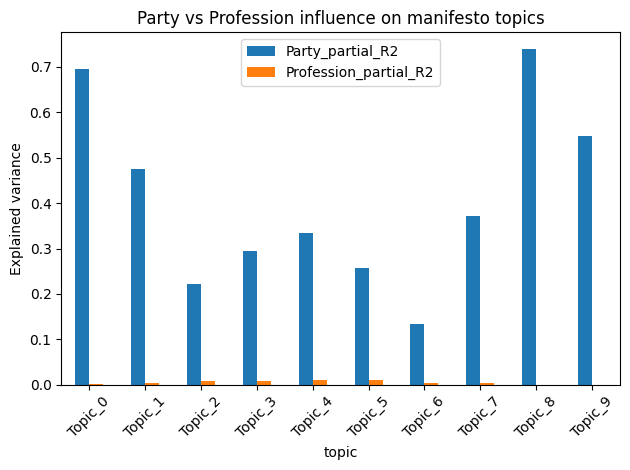

In [8]:
import matplotlib.pyplot as plt

# plot
variance_df.set_index("topic")[[
    "Party_partial_R2",
    "Profession_partial_R2"
]].plot(kind="bar")

plt.ylabel("Explained variance")
plt.title("Party vs Profession influence on manifesto topics")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [9]:
# average partial R² across topics
variance_df[["Party_partial_R2","Profession_partial_R2"]].mean()

Party_partial_R2         0.407250
Profession_partial_R2    0.005021
dtype: float64

#### Regression using YEAR as numerical

In [10]:
import statsmodels.formula.api as smf

results = []

for topic in topics:
    
    full_model = smf.ols(
        f"{topic} ~ C(party_clean) + C(profession_clean) + year", # year as numerical
        data=df
    ).fit()

    no_party = smf.ols(
        f"{topic} ~ C(profession_clean) + year",
        data=df
    ).fit()

    no_prof = smf.ols(
        f"{topic} ~ C(party_clean) + year",
        data=df
    ).fit()

    results.append({
        "topic": topic,
        "R2_total": full_model.rsquared,
        "Party_partial_R2": full_model.rsquared - no_party.rsquared,
        "Profession_partial_R2": full_model.rsquared - no_prof.rsquared
    })

variance_df_numerical = pd.DataFrame(results)
variance_df_numerical

,topic,R2_total,Party_partial_R2,Profession_partial_R2
0,Topic_0,0.863828,0.772543,0.002153
1,Topic_1,0.547538,0.484810,0.002722
2,Topic_2,0.317219,0.294767,0.008849
3,Topic_3,0.518984,0.331084,0.009040
4,Topic_4,0.504692,0.342410,0.009803
5,Topic_5,0.320609,0.262020,0.010812
6,Topic_6,0.184017,0.140781,0.004178
7,Topic_7,0.479333,0.371684,0.002865
8,Topic_8,0.977070,0.923151,0.000096
9,Topic_9,0.869326,0.676619,0.000285


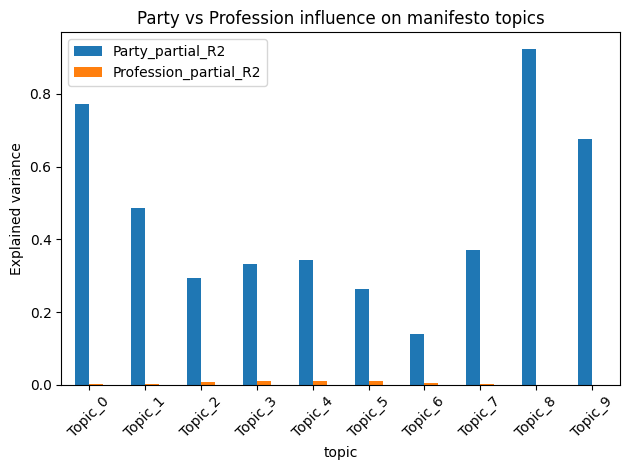

In [11]:
import matplotlib.pyplot as plt

# plot
variance_df_numerical.set_index("topic")[[
    "Party_partial_R2",
    "Profession_partial_R2"
]].plot(kind="bar")

plt.ylabel("Explained variance")
plt.title("Party vs Profession influence on manifesto topics")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [12]:
variance_df_numerical[["Party_partial_R2","Profession_partial_R2"]].mean()

Party_partial_R2         0.459987
Profession_partial_R2    0.005080
dtype: float64

In [13]:
# Mixed effects model with year as random effect
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "Topic_0 ~ C(party_clean) + C(profession_clean)",
    df,
    groups=df["year"]
)

result = model.fit()

print(result.summary())

                                 Mixed Linear Model Regression Results
Model:                             MixedLM                 Dependent Variable:                 Topic_0  
No. Observations:                  3596                    Method:                             REML     
No. Groups:                        3                       Scale:                              0.0071   
Min. group size:                   1032                    Log-Likelihood:                     3701.6970
Max. group size:                   1482                    Converged:                          Yes      
Mean group size:                   1198.7                                                               
--------------------------------------------------------------------------------------------------------
                                                              Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------------------

In [14]:
# Run mixed effects models for each topic
mixed_results = []

for topic in topics:

    model = smf.mixedlm(
        f"{topic} ~ C(party_clean) + C(profession_clean)",
        df,
        groups=df["year"]
    )

    result = model.fit()

    mixed_results.append({
        "topic": topic,
        "log_likelihood": result.llf
    })

mixed_df = pd.DataFrame(mixed_results)
mixed_df

,topic,log_likelihood
0,Topic_0,3701.697012
1,Topic_1,1917.094053
2,Topic_2,1353.713325
3,Topic_3,2509.237968
4,Topic_4,1025.171597
5,Topic_5,1613.999921
6,Topic_6,2314.079243
7,Topic_7,2116.764469
8,Topic_8,5679.266967
9,Topic_9,3277.243649


In [15]:
# Random intercept values
result.random_effects

{np.int64(1981): Group   -0.014004
 dtype: float64,
 np.int64(1988): Group   -0.011196
 dtype: float64,
 np.int64(1993): Group    0.0252
 dtype: float64}

In [16]:
# variance of the random effect
result.cov_re

,Group
Group,0.000511


### Party dispersion

In [17]:
# Extract topic columns
topics = [c for c in df.columns if c.startswith("Topic_")]
topic_matrix = df[topics].values # Extract topic columns as a matrix
topic_matrix.shape

(3596, 10)

In [18]:
# Compute average topic distributions for each party
party_centroids = df.groupby("party_clean")[topics].mean()
party_centroids

,Topic_0,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9
party_clean,,,,,,,,,,
Alliance des Français pour le progrès,0.029344,0.491440,0.064518,0.002368,0.134503,0.205474,0.016008,0.035076,0.004821,0.016447
Entente des écologistes,0.003957,0.034182,0.082128,0.020540,0.026877,0.032977,0.016113,0.006385,0.001658,0.775184
Liste d'entente populaire et nationale,0.001521,0.001812,0.002603,0.000706,0.008708,0.005235,0.009646,0.006551,0.962498,0.000719
Majorité d'union de la gauche,0.100963,0.032503,0.079679,0.579204,0.138505,0.040499,0.004547,0.021426,0.001961,0.000713
Majorité de la France,0.016371,0.085795,0.043324,0.053932,0.157021,0.054536,0.028519,0.555343,0.002208,0.002951
Majorité présidentielle,0.026305,0.284530,0.074906,0.066520,0.280017,0.077427,0.026868,0.158515,0.001150,0.003763
Majorité présidentielle pour la France unie,0.014713,0.503792,0.004456,0.006765,0.154106,0.062084,0.023258,0.225252,0.004044,0.001531
Other,0.052970,0.086136,0.277118,0.092728,0.142976,0.141282,0.094715,0.043157,0.015371,0.053546
Rassemblement des forces de gauche,0.829024,0.038998,0.027031,0.009870,0.035540,0.037517,0.005921,0.012219,0.002049,0.001831


#### Euclidean distance

In [19]:
# Compute distance of each document to its party centroid
from scipy.spatial.distance import euclidean

distances = []

for i, row in df.iterrows():
    
    party = row["party_clean"]
    doc_vector = row[topics].values
    centroid = party_centroids.loc[party].values
    
    dist = euclidean(doc_vector, centroid)
    
    distances.append(dist)

df["party_distance"] = distances

df.head()

,id,date,titulaire-liste,titulaire-profession,titulaire-age-calcule,titulaire-sexe,departement-insee,text,word_count,year,...,Topic_1,Topic_2,Topic_3,Topic_4,Topic_5,Topic_6,Topic_7,Topic_8,Topic_9,party_distance
0,EL134_L_1981_06_001_03_1_PF_02,1981-06-14,Union de la gauche,agent SNCF,35,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,900,1981,...,0.000293,0.000293,0.851032,0.000293,0.100610,0.000293,0.046306,0.000293,0.000293,0.834147
1,EL134_L_1981_06_001_03_1_PF_03,1981-06-14,Union pour une nouvelle majorité,docteur-vétérinaire,42,homme,01 - Ain,Sciences Po / fonds CEVIPOF\nJean VIAL 42 ans ...,607,1981,...,0.000410,0.000410,0.000410,0.996310,0.000410,0.000410,0.000410,0.000410,0.000410,0.407359
2,EL134_L_1981_06_001_03_1_PF_04,1981-06-14,Union pour une nouvelle majorité,médecin campagne,61,homme,01 - Ain,REPUBLIQUE FRANÇAISE - TROISIEME CIRCONSCRIPTI...,996,1981,...,0.000321,0.000321,0.000321,0.997115,0.000321,0.000321,0.000321,0.000321,0.000321,0.408159
3,EL134_L_1981_06_002_01_1_PF_01,1981-06-14,Union pour réussir le changement,professeur,non mentionné,homme,02 - Aisne,ÉLECTIONS LÉGISLATIVES - JUIN 1981\n1re Circon...,342,1981,...,0.000764,0.215010,0.533015,0.246629,0.000764,0.000763,0.000764,0.000764,0.000764,0.501834
4,EL134_L_1981_06_002_02_1_PF_02,1981-06-14,Union pour une nouvelle majorité,vétérinaire,56,homme,02 - Aisne,Sciences Po / fonds CEVIPOF\nLucien BOCHARD\nE...,497,1981,...,0.000658,0.000658,0.000658,0.863194,0.077413,0.000658,0.000658,0.000658,0.000658,0.277275


In [20]:
# Compute average distance to party centroid for each party
# idea: parties with lower average distance have more homogeneous topic distributions, 
# while those with higher average distance are more dispersed in topic space
party_dispersion = df.groupby("party_clean")["party_distance"].mean().sort_values()
party_dispersion

party_clean
Liste d'entente populaire et nationale         0.067064
Rassemblement des forces de gauche             0.211930
Entente des écologistes                        0.264091
Majorité d'union de la gauche                  0.288844
Union pour une nouvelle majorité               0.316470
Majorité présidentielle pour la France unie    0.347497
Alliance des Français pour le progrès          0.367983
Majorité de la France                          0.398486
Union pour la France                           0.399241
Union du rassemblement et du centre            0.422474
Majorité présidentielle                        0.456118
Other                                          0.575889
Name: party_distance, dtype: float64

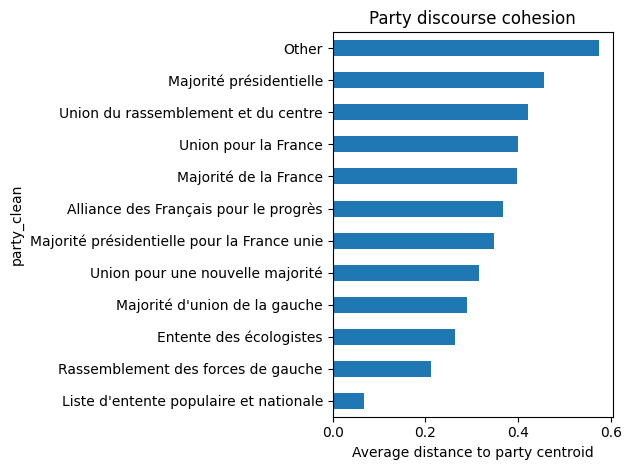

In [21]:
# plot
import matplotlib.pyplot as plt

party_dispersion.plot(kind="barh")

plt.xlabel("Average distance to party centroid")
plt.title("Party discourse cohesion")
plt.tight_layout()
plt.show()

In [22]:
# stats of distance to party centroid by party
df.groupby("party_clean")["party_distance"].agg(["mean","std","count"])

,mean,std,count
party_clean,,,
Alliance des Français pour le progrès,0.367983,0.149829,155
Entente des écologistes,0.264091,0.160773,421
Liste d'entente populaire et nationale,0.067064,0.124232,450
Majorité d'union de la gauche,0.288844,0.116470,140
Majorité de la France,0.398486,0.148209,172
Majorité présidentielle,0.456118,0.147920,55
Majorité présidentielle pour la France unie,0.347497,0.133660,287
Other,0.575889,0.177023,864
Rassemblement des forces de gauche,0.211930,0.144616,266


### Cosince distance

In [23]:
# Compute distance of each document to its party centroid using cosine distance
# idea: cosine distance captures similarity in topic distribution regardless of magnitude,
# so it may be more appropriate for comparing topic distributions
from scipy.spatial.distance import cosine

topics = [c for c in df.columns if c.startswith("Topic_")]

party_centroids = df.groupby("party_clean")[topics].mean()

distances = []

for _, row in df.iterrows():

    party = row["party_clean"]
    doc_vector = row[topics].values
    centroid = party_centroids.loc[party].values

    dist = cosine(doc_vector, centroid)

    distances.append(dist)

df["party_distance"] = distances

In [24]:
# Compute average distance to party centroid for each party
party_dispersion = (df.groupby("party_clean")["party_distance"].mean().sort_values())
party_dispersion

party_clean
Liste d'entente populaire et nationale         0.012502
Rassemblement des forces de gauche             0.042766
Entente des écologistes                        0.072100
Majorité d'union de la gauche                  0.096961
Union pour une nouvelle majorité               0.113261
Majorité présidentielle pour la France unie    0.156993
Alliance des Français pour le progrès          0.179806
Majorité de la France                          0.184296
Union pour la France                           0.213008
Union du rassemblement et du centre            0.225692
Majorité présidentielle                        0.300895
Other                                          0.432636
Name: party_distance, dtype: float64

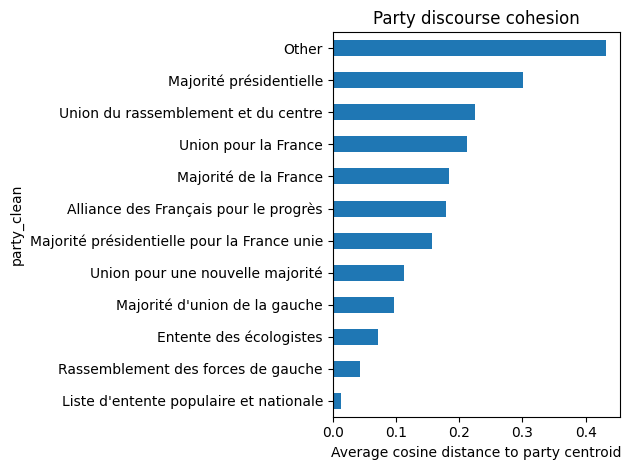

In [25]:
import matplotlib.pyplot as plt

party_dispersion.plot(kind="barh")

plt.xlabel("Average cosine distance to party centroid")
plt.title("Party discourse cohesion")
plt.tight_layout()

plt.show()

In [26]:
# party influence
party_topic_means = df.groupby("party_clean")[topics].mean()
party_influence = party_topic_means.max(axis=1)
party_influence.sort_values(ascending=False)

party_clean
Liste d'entente populaire et nationale         0.962498
Rassemblement des forces de gauche             0.829024
Entente des écologistes                        0.775184
Union pour une nouvelle majorité               0.631707
Majorité d'union de la gauche                  0.579204
Majorité de la France                          0.555343
Majorité présidentielle pour la France unie    0.503792
Alliance des Français pour le progrès          0.491440
Union pour la France                           0.398904
Union du rassemblement et du centre            0.368459
Majorité présidentielle                        0.284530
Other                                          0.277118
dtype: float64

In [27]:
# create a dataframe to compare cohesion and influence
comparison_df = pd.DataFrame({
    "cohesion": party_dispersion,
    "influence": party_influence
})

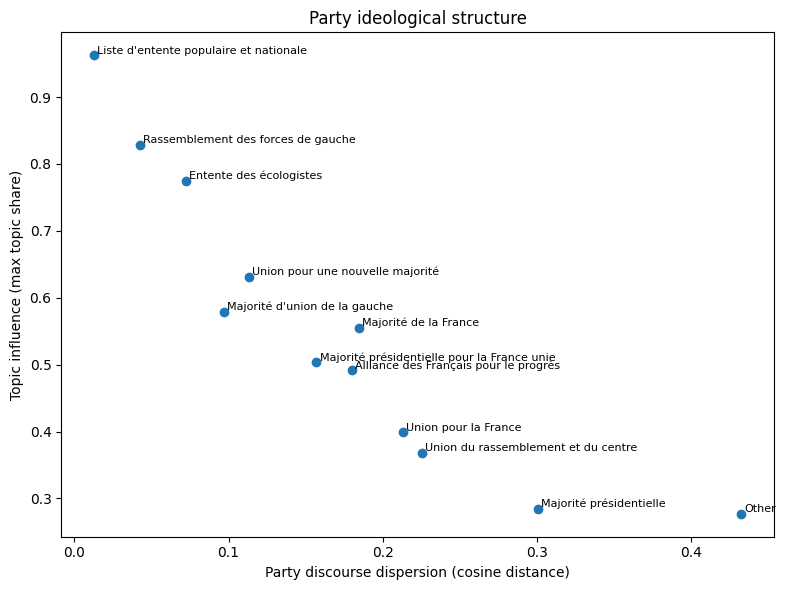

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    comparison_df["cohesion"],
    comparison_df["influence"]
)

for party, row in comparison_df.iterrows():
    plt.text(
        row["cohesion"] + 0.002,
        row["influence"] + 0.002,
        party,
        fontsize=8
    )

plt.xlabel("Party discourse dispersion (cosine distance)")
plt.ylabel("Topic influence (max topic share)")
plt.title("Party ideological structure")

plt.tight_layout()
plt.show()

### Temporal analysis

In [29]:
df["year"].unique()

array([1981, 1988, 1993])

In [30]:
years = sorted(df["year"].unique())

In [31]:
# Run regression analyses for each topic and year to see how party influence changes over time
# idea: by running separate regressions for each year, 
# we can see if the influence of party on topic distributions has increased or decreased over time, 
# which may reflect changes in party discipline or ideological polarization
import statsmodels.formula.api as smf
import pandas as pd

topics = [c for c in df.columns if c.startswith("Topic_")]

temporal_results = []

for year in years:
    
    df_year = df[df["year"] == year]
    
    for topic in topics:
        
        full = smf.ols(
            f"{topic} ~ C(party_clean) + C(profession_clean)",
            data=df_year
        ).fit()
        
        no_party = smf.ols(
            f"{topic} ~ C(profession_clean)",
            data=df_year
        ).fit()
        
        party_partial = full.rsquared - no_party.rsquared
        
        temporal_results.append({
            "year": year,
            "topic": topic,
            "party_R2": party_partial
        })

temporal_df = pd.DataFrame(temporal_results)

In [32]:
# summarize average party R² by year
temporal_summary = temporal_df.groupby("year")["party_R2"].mean()
temporal_summary

year
1981    0.191359
1988    0.371383
1993    0.228368
Name: party_R2, dtype: float64

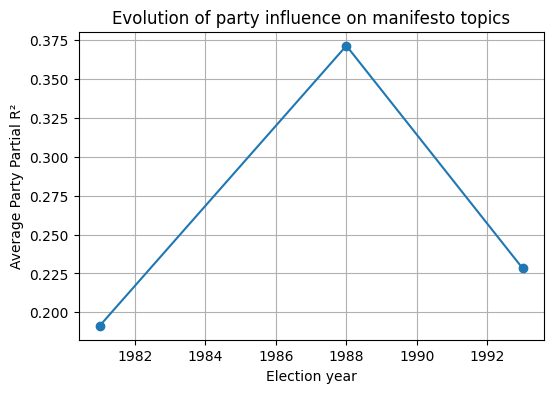

In [33]:
# plot evolution of party influence over time
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(
    temporal_summary.index,
    temporal_summary.values,
    marker="o"
)

plt.xlabel("Election year")
plt.ylabel("Average Party Partial R²")
plt.title("Evolution of party influence on manifesto topics")

plt.grid(True)
plt.show()

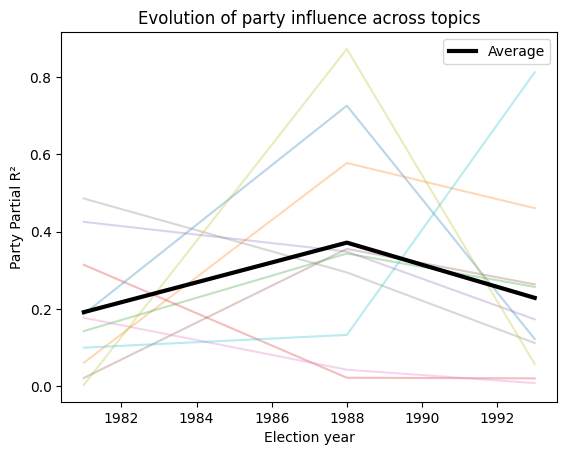

In [34]:
# plot Evolution of party influence across topics
for topic in topics:
    
    topic_data = temporal_df[temporal_df["topic"] == topic]
    
    plt.plot(
        topic_data["year"],
        topic_data["party_R2"],
        alpha=0.3
    )

plt.plot(
    temporal_summary.index,
    temporal_summary.values,
    color="black",
    linewidth=3,
    label="Average"
)

plt.legend()
plt.xlabel("Election year")
plt.ylabel("Party Partial R²")
plt.title("Evolution of party influence across topics")

plt.show()